# Cuaderno 2 — Construcción de features y variable objetivo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## Objetivo

Transformar los datos crudos descargados en el Cuaderno 1 en un dataset listo para el modelo de machine learning. Este cuaderno cubre:

1. **Carga optimizada**: tipos de datos eficientes para minimizar uso de memoria
2. **Limpieza de fechas**: eliminación de registros con fechas imposibles
3. **Filtrado de registros**: separación de variables de balance y de flujo
4. **Destrimestralización**: recuperar valores trimestrales de reportes acumulados
5. **Transformación de formato**: de formato largo a formato ancho (pivot)
6. **Análisis exploratorio (EDA)**: distribuciones, correlaciones y patrones clave
7. **Construcción de la variable objetivo Y**: definir qué empresa alcanza el breakeven
8. **Ingeniería de features**: variables derivadas con mayor poder predictivo
9. **Control de calidad**: cobertura de datos y eliminación de variables inutilizables

---

## Decisiones metodológicas clave

### Variable objetivo
Y=1 si el FCF operativo **promedio** de los próximos 4 trimestres es positivo, Y=0 si no. Se usa el promedio (no el máximo) para capturar breakeven sostenido — una empresa que tiene un trimestre positivo por una venta puntual no cuenta como breakeven real.

### Filtro de universo
Solo se incluyen trimestres donde la empresa tenía FCF operativo negativo. La pregunta de investigación aplica únicamente a empresas que hoy queman caja.

### Tratamiento de outliers
Winsorización al percentil 1-99. No se eliminan los casos extremos — se preservan como información válida para el modelo, pero se limitan para que no distorsionen el entrenamiento.

### Eliminación de variables con baja cobertura
Se eliminan variables con menos del 15% de cobertura: con tan pocos datos disponibles, la imputación introduce más ruido que señal.

## 1. Configuración inicial y carga de datos

### Estrategia de memoria

El dataset crudo tiene 4.4 millones de registros. Cargado con tipos por defecto ocupa ~3 GB en RAM — inmanejable en un entorno de 8 GB. La solución es usar tipos de datos eficientes desde la carga:

- **`category`** para columnas con pocos valores únicos repetidos (ticker, sector, variable, etc.) — reduce el uso de memoria hasta 20x en strings repetitivos
- **`float32`** en vez de `float64` para valores numéricos — divide la memoria a la mitad
- **`Int32`** para el año fiscal — entero con soporte para NaN
- Eliminar columnas innecesarias desde la carga (`usecols`)

Con esta estrategia el dataset pasa de ~3 GB a ~141 MB.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

# Identidad visual del proyecto
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"
cmap_custom = LinearSegmentedColormap.from_list(
    "juan", [juan_colors[0], "white", juan_colors[5]], N=256
)

def estilo_ax(ax, orientacion="vertical"):
    """Aplica el estilo visual estándar del proyecto a un eje."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.yaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Carga optimizada
df = pd.read_csv(
    "../datos/crudos/variables_financieras_sec.csv.gz",
    compression="gzip",
    usecols=["ticker", "sector", "bolsa", "variable", "form",
             "start", "end", "val", "fp", "fy"],
    dtype={
        "ticker":   "category",
        "variable": "category",
        "form":     "category",
        "bolsa":    "category",
        "sector":   "category",
        "fp":       "category",
        "val":      "float32",
    }
)

df["start"] = pd.to_datetime(df["start"], errors="coerce")
df["end"]   = pd.to_datetime(df["end"],   errors="coerce")
df["fy"]    = pd.to_numeric(df["fy"], errors="coerce").astype("Int32")

memoria_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Dataset cargado: {df.shape}")
print(f"Memoria: {memoria_mb:.1f} MB")
print(f"Empresas: {df['ticker'].nunique():,}")
print(f"Variables: {df['variable'].nunique()}")

Dataset cargado: (4472817, 10)
Memoria: 141.0 MB
Empresas: 1,626
Variables: 40


## 2. Limpieza de fechas

El dataset contiene registros con fechas imposibles — algunos anteriores al año 2000 (cuando el Russell 2500 aún no existía en su forma actual) y uno en 2028 (fecha futura). Estos corresponden a errores tipográficos en los reportes originales de la SEC.

Con solo 237 registros afectados sobre 4.4 millones (0.005%), su eliminación no tiene impacto en los resultados.

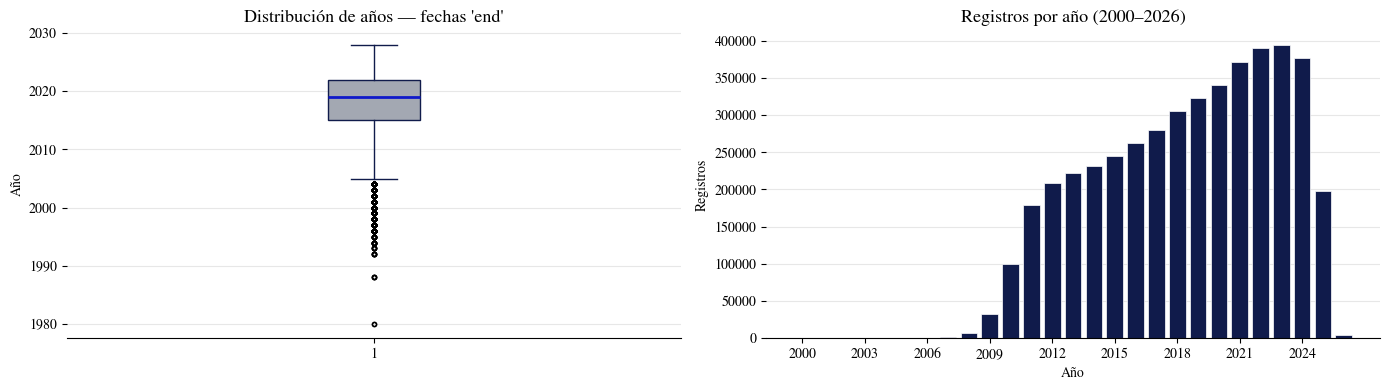

Registros con fechas imposibles:
  Antes de 2000:      236
  Después de 2026:    1
  Total a eliminar:   237

Registros eliminados: 237 (0.005%)
Registros restantes:  4,472,580


In [65]:
# Visualizar distribución de fechas para identificar outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anos = df["end"].dt.year.dropna()

# Gráfico 1 — boxplot de años
estilo_ax(axes[0], "vertical")
axes[0].boxplot(anos, vert=True, patch_artist=True,
                boxprops=dict(facecolor=juan_colors[2], color=juan_colors[0]),
                medianprops=dict(color=juan_colors[4], linewidth=2),
                whiskerprops=dict(color=juan_colors[0]),
                capprops=dict(color=juan_colors[0]),
                flierprops=dict(marker="o", color=juan_colors[5], markersize=3))
axes[0].set_title("Distribución de años — fechas 'end'", fontfamily=FUENTE, fontsize=13)
axes[0].set_ylabel("Año", fontfamily=FUENTE)

# Gráfico 2 — histograma de años válidos
estilo_ax(axes[1], "vertical")
anos_validos = anos[(anos >= 2000) & (anos <= 2026)]
conteo = anos_validos.value_counts().sort_index()
axes[1].bar(conteo.index, conteo.values, color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Registros por año (2000–2026)", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("Año", fontfamily=FUENTE)
axes[1].set_ylabel("Registros", fontfamily=FUENTE)
axes[1].set_xticks(range(2000, 2027, 3))

plt.tight_layout()
plt.show()

print(f"Registros con fechas imposibles:")
print(f"  Antes de 2000:      {(df['end'].dt.year < 2000).sum():,}")
print(f"  Después de 2026:    {(df['end'].dt.year > 2026).sum():,}")
print(f"  Total a eliminar:   {((df['end'].dt.year < 2000) | (df['end'].dt.year > 2026)).sum():,}")

# Aplicar filtro
n_antes = len(df)
df = df[(df["end"].dt.year >= 2000) & (df["end"].dt.year <= 2026)].copy()
print(f"\nRegistros eliminados: {n_antes - len(df):,} ({(n_antes - len(df))/n_antes*100:.3f}%)")
print(f"Registros restantes:  {len(df):,}")

## 3. Filtrado de registros trimestrales

Los datos en SEC EDGAR se reportan de dos formas según el tipo de variable:

**Variables de balance** (caja, activos, pasivos, etc.): son una "foto" del estado de la empresa en un momento dado — no tienen un período de inicio y fin, sino un punto en el tiempo. Se filtran por el campo `fp` (fiscal period) que indica el trimestre: Q1, Q2, Q3, Q4.

**Variables de flujo** (FCF, ingresos, utilidades, etc.): son acumulativas dentro del año fiscal. La SEC frecuentemente reporta el valor acumulado del año hasta ese punto — por ejemplo, el Q3 puede contener el valor de Q1+Q2+Q3. Para obtener el valor trimestral puro se aplica **destrimestralización**.

El filtro para variables de flujo se basa en la duración en días entre `start` y `end`:
- **80–100 días**: trimestre puro ✓
- **~180 días**: acumulado Q1+Q2
- **~274 días**: acumulado Q1+Q2+Q3
- **~365 días**: anual completo (10-K)

Variables de balance: 17
Variables de flujo:   23

Balance después de filtro fp: 1,374,750


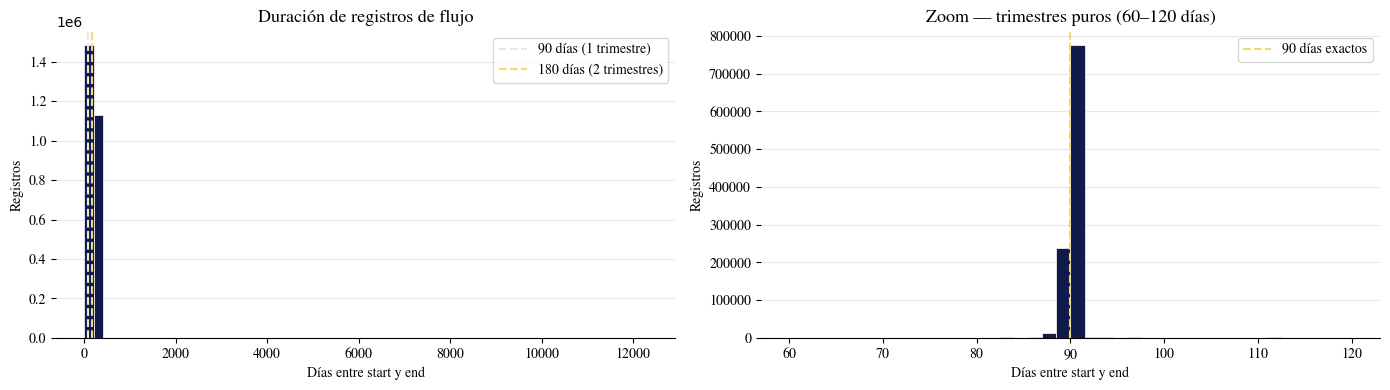

Flujo trimestral puro:  1,040,415 (39.8%)
Flujo acumulado:        1,576,935 (60.2%)


In [66]:
variables_balance = [
    "activos_corrientes", "activos_totales", "caja",
    "cuentas_por_cobrar", "cuentas_por_pagar", "deuda_corto_plazo",
    "deuda_largo_plazo", "inventario", "pasivos_corrientes",
    "activos_intangibles", "goodwill", "ppe_neto", "patrimonio",
    "retained_earnings", "ingresos_diferidos", "impuestos_pagados",
    "acciones_circulacion"
]

variables_flujo = [v for v in df["variable"].cat.categories if v not in variables_balance]

# Separar
df_balance = df[df["variable"].isin(variables_balance)].copy()
df_flujo   = df[~df["variable"].isin(variables_balance)].copy()

# Filtrar balance por período fiscal
df_balance = df_balance[df_balance["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

# Calcular duración para flujo
df_flujo["duracion_dias"] = (df_flujo["end"] - df_flujo["start"]).dt.days

print(f"Variables de balance: {len(variables_balance)}")
print(f"Variables de flujo:   {len(variables_flujo)}")
print(f"\nBalance después de filtro fp: {len(df_balance):,}")

# Visualizar distribución de duraciones en flujo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    estilo_ax(ax, "vertical")

# Distribución completa
axes[0].hist(df_flujo["duracion_dias"].dropna(), bins=60,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].axvline(90,  color=juan_colors[3], linewidth=1.5, linestyle="--", label="90 días (1 trimestre)")
axes[0].axvline(180, color=juan_colors[5], linewidth=1.5, linestyle="--", label="180 días (2 trimestres)")
axes[0].set_title("Duración de registros de flujo", fontfamily=FUENTE, fontsize=13)
axes[0].set_xlabel("Días entre start y end", fontfamily=FUENTE)
axes[0].set_ylabel("Registros", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE})

# Zoom en trimestres puros
zoom = df_flujo[df_flujo["duracion_dias"].between(60, 120)]
axes[1].hist(zoom["duracion_dias"].dropna(), bins=40,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].axvline(90, color=juan_colors[5], linewidth=1.5, linestyle="--", label="90 días exactos")
axes[1].set_title("Zoom — trimestres puros (60–120 días)", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("Días entre start y end", fontfamily=FUENTE)
axes[1].set_ylabel("Registros", fontfamily=FUENTE)
axes[1].legend(prop={"family": FUENTE})

plt.tight_layout()
plt.show()

df_flujo_puro = df_flujo[df_flujo["duracion_dias"].between(80, 100)].copy()
df_flujo_acum = df_flujo[~df_flujo["duracion_dias"].between(80, 100)].copy()

print(f"Flujo trimestral puro:  {len(df_flujo_puro):,} ({len(df_flujo_puro)/len(df_flujo)*100:.1f}%)")
print(f"Flujo acumulado:        {len(df_flujo_acum):,} ({len(df_flujo_acum)/len(df_flujo)*100:.1f}%)")

## 4. Destrimestralización

Para recuperar los valores trimestrales puros de los registros acumulados, restamos el acumulado del período anterior:

- Q1 puro = Q1 acumulado (no hay período anterior)
- Q2 puro = Q2 acumulado − Q1 acumulado
- Q3 puro = Q3 acumulado − Q2 acumulado
- Q4 puro = Q4 acumulado − Q3 acumulado

Solo se procesan registros con duración entre 150 y 400 días — los de duración extrema (< 20 días o > 400 días) son errores de reporte y se descartan.

In [67]:
# Filtrar acumulados en rango válido
df_flujo_acum = df_flujo_acum[df_flujo_acum["duracion_dias"].between(150, 400)].copy()

# Destrimestralizar
df_flujo_acum = df_flujo_acum.sort_values(["ticker", "variable", "fy", "end"]).copy()
df_flujo_acum["val_anterior"] = df_flujo_acum.groupby(
    ["ticker", "variable", "fy"], observed=True
)["val"].shift(1)
df_flujo_acum["val_trimestral"] = df_flujo_acum["val"] - df_flujo_acum["val_anterior"]

# Q1: el acumulado ya es el trimestral puro
mask_q1 = df_flujo_acum["val_anterior"].isna()
df_flujo_acum.loc[mask_q1, "val_trimestral"] = df_flujo_acum.loc[mask_q1, "val"]

df_flujo_acum = df_flujo_acum.dropna(subset=["val_trimestral"]).copy()
df_flujo_acum["val"] = df_flujo_acum["val_trimestral"].astype("float32")
df_flujo_acum = df_flujo_acum.drop(columns=["val_anterior", "val_trimestral", "duracion_dias"])

# Combinar puro + destrimestralizado
df_flujo_final = pd.concat([
    df_flujo_puro.drop(columns=["duracion_dias"]),
    df_flujo_acum
], ignore_index=True)

print(f"Flujo puro original:      {len(df_flujo_puro):,}")
print(f"Flujo destrimestralizado: {len(df_flujo_acum):,}")
print(f"Flujo total final:        {len(df_flujo_final):,}")

Flujo puro original:      1,040,415
Flujo destrimestralizado: 1,565,597
Flujo total final:        2,606,012


## 5. Consolidación y pivot

Combinamos las variables de flujo y balance en un único dataset, luego aplicamos el pivot para pasar de formato largo (una variable por fila) a formato ancho (una empresa-trimestre por fila).

Si existen duplicados para la misma empresa, trimestre y variable, se promedian.

Flujo final:   2,606,012
Balance final: 1,374,750
Total limpio:  3,980,762


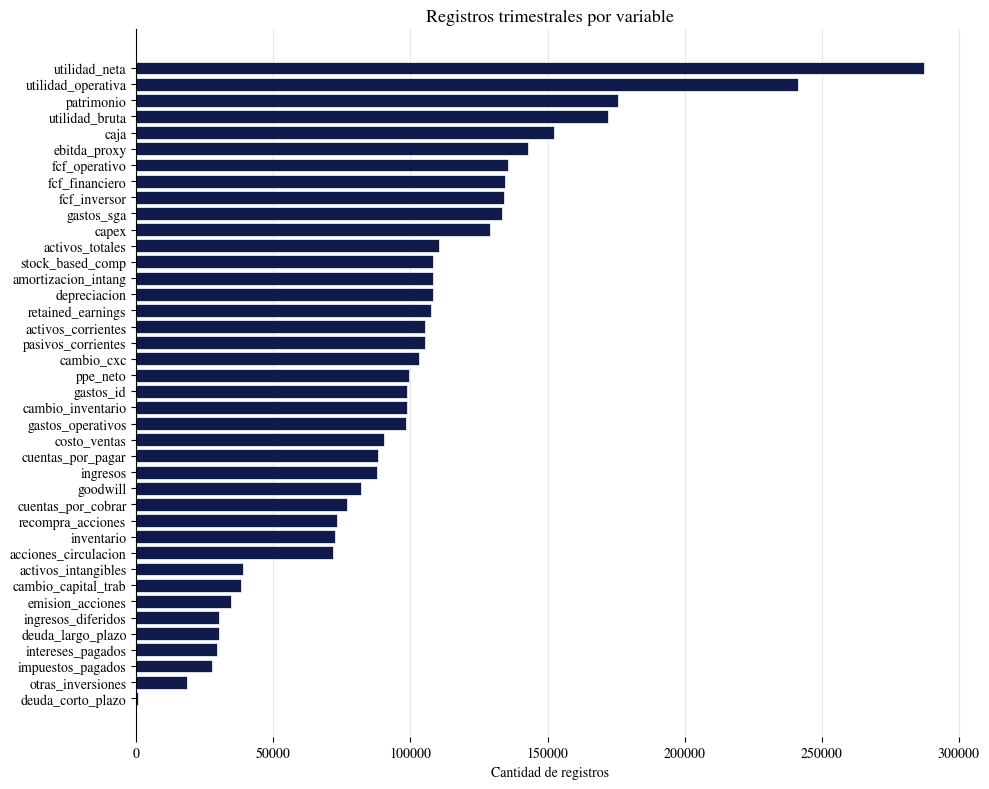


Shape después del pivot: (80718, 44)
Empresas: 1,626
Trimestres por empresa (promedio): 49.6
Equivale a ~12.4 años de historia por empresa


In [68]:
# Consolidar
df_limpio = pd.concat([df_flujo_final, df_balance], ignore_index=True)

print(f"Flujo final:   {len(df_flujo_final):,}")
print(f"Balance final: {len(df_balance):,}")
print(f"Total limpio:  {len(df_limpio):,}")

# Gráfico — registros por variable
conteo = df_limpio["variable"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
estilo_ax(ax, "horizontal")
ax.barh(conteo.index, conteo.values, color=juan_colors[0], edgecolor="white", linewidth=0.5)
ax.set_title("Registros trimestrales por variable", fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Cantidad de registros", fontfamily=FUENTE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

# Pivot
df_ancho = df_limpio.pivot_table(
    index=["ticker", "sector", "bolsa", "end"],
    columns="variable",
    values="val",
    aggfunc="mean",
    observed=True
).reset_index()

df_ancho.columns.name = None
df_ancho = df_ancho.sort_values(["ticker", "end"]).reset_index(drop=True)

anos_historia = len(df_ancho) / df_ancho["ticker"].nunique() / 4
print(f"\nShape después del pivot: {df_ancho.shape}")
print(f"Empresas: {df_ancho['ticker'].nunique():,}")
print(f"Trimestres por empresa (promedio): {len(df_ancho) / df_ancho['ticker'].nunique():.1f}")
print(f"Equivale a ~{anos_historia:.1f} años de historia por empresa")

## 6. Construcción de la variable objetivo Y

La variable objetivo Y responde la pregunta central de la tesis: **¿alcanzará esta empresa el punto de equilibrio de flujo de caja en los próximos 4 trimestres?**

$$Y_t = \begin{cases} 1 & \text{si } \overline{FCF}_{t+1, t+2, t+3, t+4} > 0 \\ 0 & \text{en caso contrario} \end{cases}$$

**Filtro de universo:** solo se incluyen trimestres donde el FCF operativo es negativo — la pregunta de investigación solo aplica a empresas que hoy queman caja.

### Resultado: balance casi perfecto

A diferencia de lo que ocurre con índices como el S&P 500 (dominado por empresas consolidadas), el Russell 2500 con empresas small/mid cap produce un balance natural de ~48% Y=1 y ~52% Y=0. Este balance no requiere técnicas de corrección como SMOTE o class weights.

In [69]:
def calcular_fcf_futuro(grupo):
    """Para cada trimestre T, promedia el FCF en T+1, T+2, T+3, T+4."""
    fcf = grupo["fcf_operativo"].values
    resultado = []
    for i in range(len(fcf)):
        futuros = fcf[i+1:i+5]
        if len(futuros) == 4 and not np.isnan(futuros).all():
            resultado.append(np.nanmean(futuros))
        else:
            resultado.append(np.nan)
    grupo = grupo.copy()
    grupo["fcf_promedio_futuro"] = resultado
    return grupo


df_ancho = df_ancho.groupby("ticker", group_keys=False, observed=True).apply(
    calcular_fcf_futuro, include_groups=True
)

df_ancho["Y"] = (df_ancho["fcf_promedio_futuro"] > 0).astype(float)
df_ancho.loc[df_ancho["fcf_promedio_futuro"].isna(), "Y"] = np.nan

# Filtrar universo: FCF negativo + Y válida
df_modelo = df_ancho[
    (df_ancho["fcf_operativo"] < 0) &
    (df_ancho["Y"].notna())
].copy()

print(f"Total filas: {len(df_ancho):,}")
print(f"Filas con Y válida: {df_ancho['Y'].notna().sum():,}")
print(f"Dataset del modelo: {len(df_modelo):,}")
print(f"Y=1 (breakeven): {(df_modelo['Y']==1).sum():,} ({df_modelo['Y'].mean()*100:.1f}%)")
print(f"Y=0 (no alcanza): {(df_modelo['Y']==0).sum():,} ({(1-df_modelo['Y'].mean())*100:.1f}%)")

Total filas: 80,718
Filas con Y válida: 69,362
Dataset del modelo: 27,382
Y=1 (breakeven): 13,209 (48.2%)
Y=0 (no alcanza): 14,173 (51.8%)


/tmp/ipykernel_14202/1993547402.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ancho = df_ancho.groupby("ticker", group_keys=False, observed=True).apply(


## 7. Análisis exploratorio (EDA)

Antes de construir las variables derivadas, analizamos las distribuciones y patrones clave del dataset para entender qué nos vamos a encontrar en el modelado.

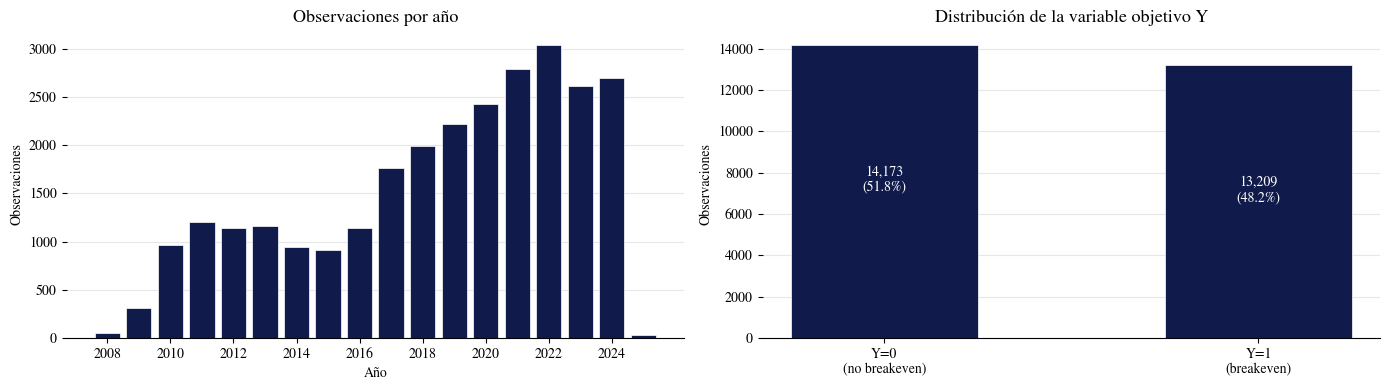

In [70]:
# 7.1 Distribución temporal y balance de Y
df_modelo["ano"] = pd.to_datetime(df_modelo["end"]).dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Observaciones por año
estilo_ax(axes[0], "vertical")
conteo_ano = df_modelo["ano"].value_counts().sort_index()
axes[0].bar(conteo_ano.index, conteo_ano.values,
            color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].set_title("Observaciones por año", fontfamily=FUENTE, fontsize=13)
axes[0].set_xlabel("Año", fontfamily=FUENTE)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
axes[0].set_xticks(range(2008, 2026, 2))
for label in axes[0].get_xticklabels():
    label.set_fontfamily(FUENTE)

# Distribución de Y
estilo_ax(axes[1], "vertical")
conteo_y = df_modelo["Y"].value_counts().sort_index()
axes[1].bar(["Y=0\n(no breakeven)", "Y=1\n(breakeven)"],
            conteo_y.values,
            color=juan_colors[0],
            edgecolor="white", linewidth=0.5, width=0.5)
axes[1].set_title("Distribución de la variable objetivo Y", fontfamily=FUENTE, fontsize=13)
axes[1].set_ylabel("Observaciones", fontfamily=FUENTE)
for i, v in enumerate(conteo_y.values):
    axes[1].text(i, v / 2, f"{v:,}\n({v/len(df_modelo)*100:.1f}%)",
                 ha="center", fontfamily=FUENTE, fontsize=10, color='white')

plt.tight_layout()
plt.show()

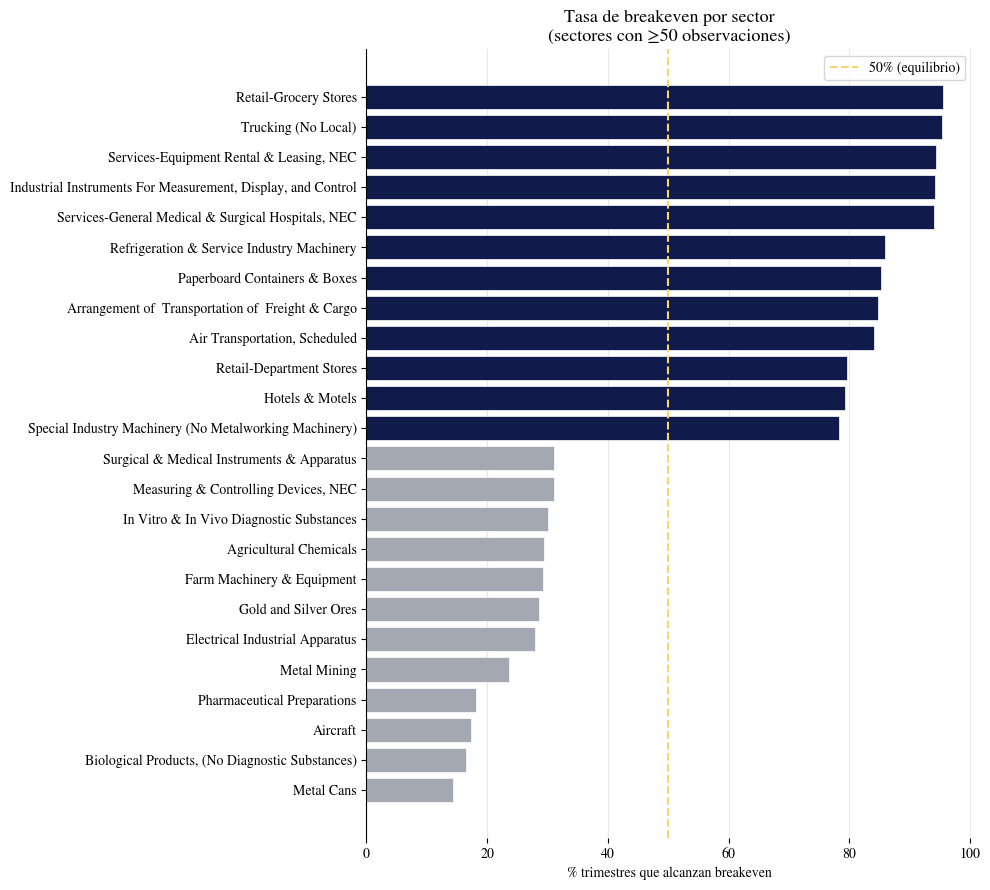

In [71]:
# 7.2 Tasa de breakeven por sector (top y bottom 15)
tasa_sector = (
    df_modelo.groupby("sector", observed=True)["Y"]
    .agg(tasa_breakeven="mean", observaciones="count")
    .query("observaciones >= 50")  # solo sectores con suficientes datos
    .sort_values("tasa_breakeven")
)

# Mostrar top y bottom 12
df_plot = pd.concat([tasa_sector.head(12), tasa_sector.tail(12)])

fig, ax = plt.subplots(figsize=(10, 9))
estilo_ax(ax, "horizontal")
colores = [juan_colors[2]] * 12 + [juan_colors[0]] * 12
ax.barh(df_plot.index, df_plot["tasa_breakeven"] * 100,
        color=colores, edgecolor="white", linewidth=0.5)
ax.axvline(50, color=juan_colors[5], linewidth=1.5, linestyle="--", label="50% (equilibrio)")
ax.set_title("Tasa de breakeven por sector\n(sectores con ≥50 observaciones)",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("% trimestres que alcanzan breakeven", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

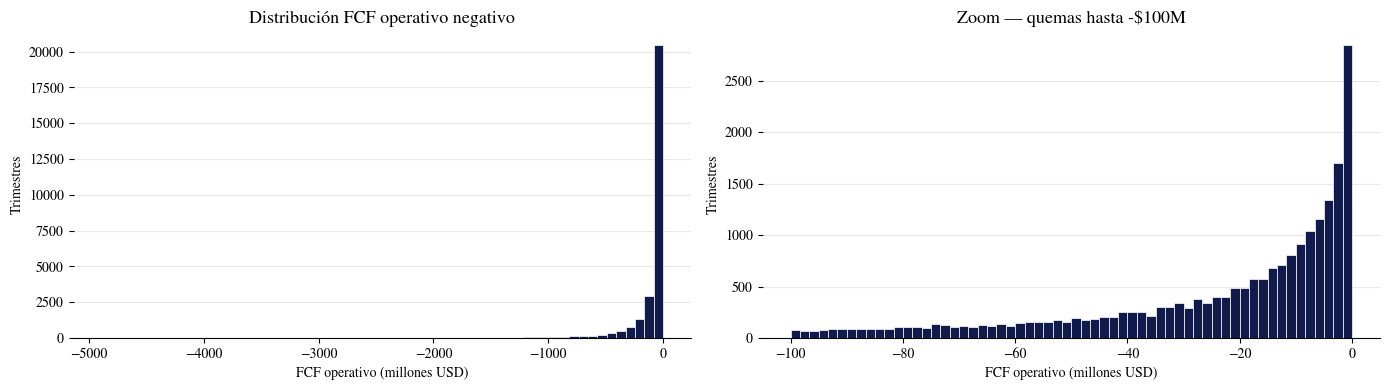

Quema leve    (> -$10M):          8,993 trimestres (32.8%)
Quema moderada (-$10M a -$100M):  12,350 trimestres (45.1%)
Quema severa  (< -$100M):         6,039 trimestres (22.1%)


In [72]:
# 7.3 Distribución del FCF negativo
fcf_neg = df_modelo["fcf_operativo"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    estilo_ax(ax, "vertical")

axes[0].hist(fcf_neg / 1e6, bins=60,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución FCF operativo negativo", fontfamily=FUENTE, fontsize=13)
axes[0].set_xlabel("FCF operativo (millones USD)", fontfamily=FUENTE)
axes[0].set_ylabel("Trimestres", fontfamily=FUENTE)

fcf_zoom = fcf_neg[fcf_neg >= -100e6]
axes[1].hist(fcf_zoom / 1e6, bins=60,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Zoom — quemas hasta -$100M", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("FCF operativo (millones USD)", fontfamily=FUENTE)
axes[1].set_ylabel("Trimestres", fontfamily=FUENTE)

plt.tight_layout()
plt.show()

leve     = (fcf_neg > -10e6).sum()
moderada = ((fcf_neg <= -10e6) & (fcf_neg > -100e6)).sum()
severa   = (fcf_neg <= -100e6).sum()
print(f"Quema leve    (> -$10M):          {leve:,} trimestres ({leve/len(fcf_neg)*100:.1f}%)")
print(f"Quema moderada (-$10M a -$100M):  {moderada:,} trimestres ({moderada/len(fcf_neg)*100:.1f}%)")
print(f"Quema severa  (< -$100M):         {severa:,} trimestres ({severa/len(fcf_neg)*100:.1f}%)")

## 8. Ingeniería de features

Las variables descargadas de la SEC son valores absolutos en dólares. Para el modelo son más útiles variables relativas y derivadas que capturan la dinámica del negocio independientemente del tamaño de la empresa.

Se construyen 11 variables derivadas:

| Variable | Fórmula | Interpretación |
|---|---|---|
| `burn_rate` | `\|FCF operativo\|` | Cuánto quema por trimestre |
| `runway` | `caja / burn_rate` | Trimestres de caja disponibles |
| `capital_trabajo` | `activos_corrientes − pasivos_corrientes` | Liquidez neta de corto plazo |
| `margen_bruto` | `utilidad_bruta / ingresos` | Eficiencia del negocio core |
| `margen_operativo` | `utilidad_operativa / ingresos` | Eficiencia operativa total |
| `margen_neto` | `utilidad_neta / ingresos` | Rentabilidad final |
| `ratio_id` | `gastos_id / ingresos` | Intensidad de inversión en innovación |
| `ratio_deuda` | `deuda_largo_plazo / activos_totales` | Apalancamiento financiero |
| `ratio_corriente` | `activos_corrientes / pasivos_corrientes` | Liquidez de corto plazo |
| `rotacion_activos` | `ingresos / activos_totales` | Eficiencia en uso de activos |
| `intensidad_capex` | `\|capex\| / ingresos` | Intensidad de inversión en activos fijos |

### Tratamiento de outliers — winsorización

Las variables derivadas pueden generar valores extremos. En lugar de eliminar esos registros, se aplica **winsorización**: los valores por debajo del percentil 1 y por encima del percentil 99 se reemplazan por esos límites. Esto preserva la información de los casos extremos sin que distorsionen el entrenamiento.

Variables derivadas creadas y winsorizadas.
Shape: (27382, 58)


/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


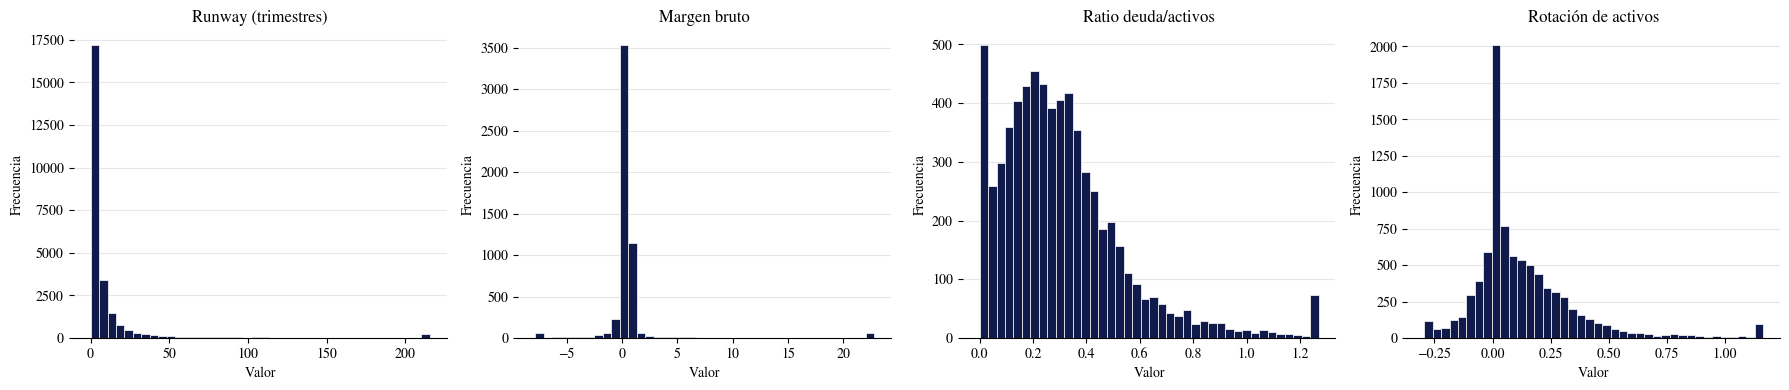

In [73]:
df_modelo = df_modelo.copy()

# Construir variables derivadas
df_modelo["burn_rate"]        = df_modelo["fcf_operativo"].abs()
df_modelo["runway"]           = df_modelo["caja"] / df_modelo["burn_rate"]
df_modelo["capital_trabajo"]  = df_modelo["activos_corrientes"] - df_modelo["pasivos_corrientes"]
df_modelo["margen_bruto"]     = df_modelo["utilidad_bruta"] / df_modelo["ingresos"]
df_modelo["margen_operativo"] = df_modelo["utilidad_operativa"] / df_modelo["ingresos"]
df_modelo["margen_neto"]      = df_modelo["utilidad_neta"] / df_modelo["ingresos"]
df_modelo["ratio_id"]         = df_modelo["gastos_id"] / df_modelo["ingresos"]
df_modelo["ratio_deuda"]      = df_modelo["deuda_largo_plazo"] / df_modelo["activos_totales"]
df_modelo["ratio_corriente"]  = df_modelo["activos_corrientes"] / df_modelo["pasivos_corrientes"]
df_modelo["rotacion_activos"] = df_modelo["ingresos"] / df_modelo["activos_totales"]
df_modelo["intensidad_capex"] = df_modelo["capex"].abs() / df_modelo["ingresos"]

# Winsorización al percentil 1-99
variables_winsorizables = [
    "runway", "burn_rate", "capital_trabajo",
    "margen_bruto", "margen_operativo", "margen_neto",
    "ratio_id", "ratio_deuda", "ratio_corriente",
    "rotacion_activos", "intensidad_capex"
]

for var in variables_winsorizables:
    p01 = df_modelo[var].quantile(0.01)
    p99 = df_modelo[var].quantile(0.99)
    df_modelo[var] = df_modelo[var].clip(lower=p01, upper=p99)

print(f"Variables derivadas creadas y winsorizadas.")
print(f"Shape: {df_modelo.shape}")

# Gráfico — distribución de variables derivadas clave
vars_plot  = ["runway", "margen_bruto", "ratio_deuda", "rotacion_activos"]
titulos    = ["Runway (trimestres)", "Margen bruto", "Ratio deuda/activos", "Rotación de activos"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, var, titulo in zip(axes, vars_plot, titulos):
    estilo_ax(ax, "vertical")
    ax.hist(df_modelo[var].dropna(), bins=40,
            color=juan_colors[0], edgecolor="white", linewidth=0.5)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=12)
    ax.set_xlabel("Valor", fontfamily=FUENTE)
    ax.set_ylabel("Frecuencia", fontfamily=FUENTE)

plt.tight_layout()
plt.show()

## 9. Control de calidad — cobertura de variables

Analizamos qué porcentaje de datos está disponible para cada variable. Variables con cobertura muy baja introducen más ruido que señal al ser imputadas.

**Criterio de eliminación:** variables con menos del 15% de cobertura.

Variables eliminadas:
- **`deuda_corto_plazo`** (0.5%): con solo 135 registros sobre 27.382 observaciones, esta variable es prácticamente inutilizable. La baja cobertura refleja que pocas empresas del Russell 2500 reportan deuda de corto plazo como concepto separado en SEC EDGAR.
- **`otras_inversiones`** (11.1%): proxy de adquisiciones puntuales. La baja cobertura refleja que las adquisiciones son eventos esporádicos, no recurrentes por trimestre.

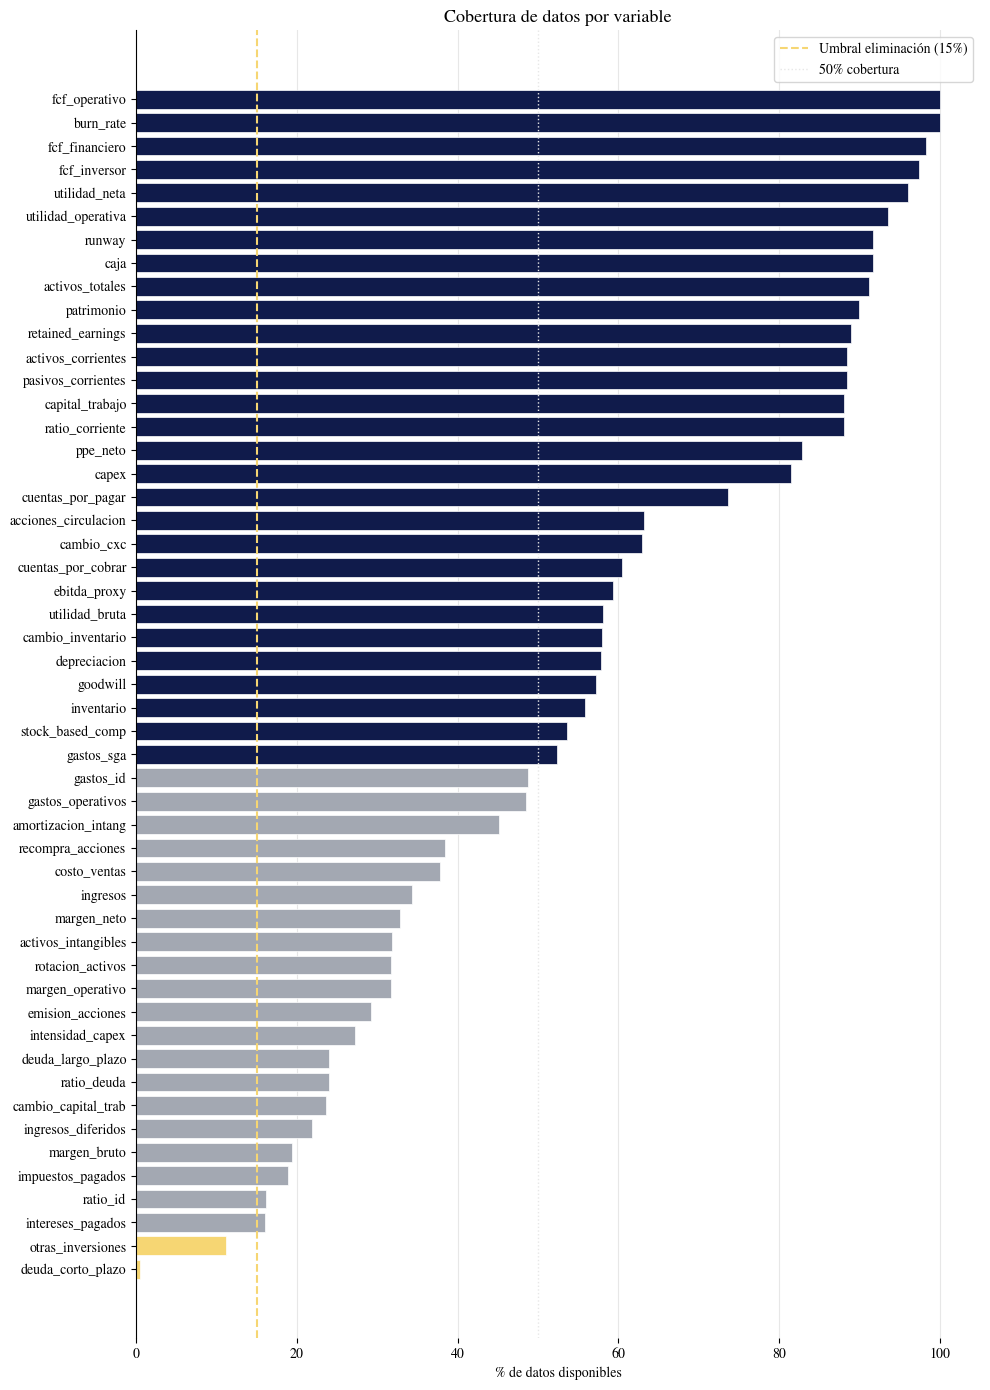

Variables eliminadas: ['deuda_corto_plazo', 'otras_inversiones']
Features restantes: 49
Shape final: (27382, 56)


In [74]:
no_features = ["ticker", "sector", "bolsa", "end", "ano", "fcf_promedio_futuro", "Y"]
features = [c for c in df_modelo.columns if c not in no_features]

cobertura = df_modelo[features].notna().mean().sort_values()

# Gráfico de cobertura
fig, ax = plt.subplots(figsize=(10, 14))
estilo_ax(ax, "horizontal")
colores_cob = [juan_colors[5] if v < 0.15 else
               juan_colors[2] if v < 0.50 else
               juan_colors[0] for v in cobertura.values]
ax.barh(cobertura.index, cobertura.values * 100,
        color=colores_cob, edgecolor="white", linewidth=0.5)
ax.axvline(15, color=juan_colors[5], linewidth=1.5, linestyle="--", label="Umbral eliminación (15%)")
ax.axvline(50, color=juan_colors[3], linewidth=1.0, linestyle=":", label="50% cobertura")
ax.set_title("Cobertura de datos por variable", fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("% de datos disponibles", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

# Eliminar variables con < 15% cobertura
cols_eliminar = ["deuda_corto_plazo", "otras_inversiones"]
df_modelo = df_modelo.drop(columns=cols_eliminar, errors="ignore")
features  = [f for f in features if f not in cols_eliminar]

print(f"Variables eliminadas: {cols_eliminar}")
print(f"Features restantes: {len(features)}")
print(f"Shape final: {df_modelo.shape}")

## 10. Matriz de correlaciones

Analizamos las correlaciones entre variables para anticipar posibles problemas de multicolinealidad en el modelo y entender qué señales financieras se mueven juntas.

### Hallazgos clave

**Correlación con Y:**
- `ratio_corriente` es la más correlacionada negativamente — empresas con mayor liquidez de corto plazo paradójicamente no alcanzan el breakeven con más frecuencia. Esto puede reflejar que las empresas acumulan caja precisamente porque están quemando efectivo y necesitan reservas.
- `activos_totales` y `patrimonio` son las más positivas — el tamaño predice el breakeven, lo que confirma el perfil del Russell 2500: empresas más maduras dentro del segmento small/mid cap tienen más probabilidad de alcanzarlo.

**Multicolinealidad esperada:**
- Variables de tamaño absoluto están altamente correlacionadas entre sí (activos, ingresos, patrimonio)
- Variables derivadas de las mismas fuentes también correlacionan (márgenes entre sí)
- Los modelos de árboles (Random Forest, Gradient Boosting) son robustos a la multicolinealidad — no es un problema para el modelado

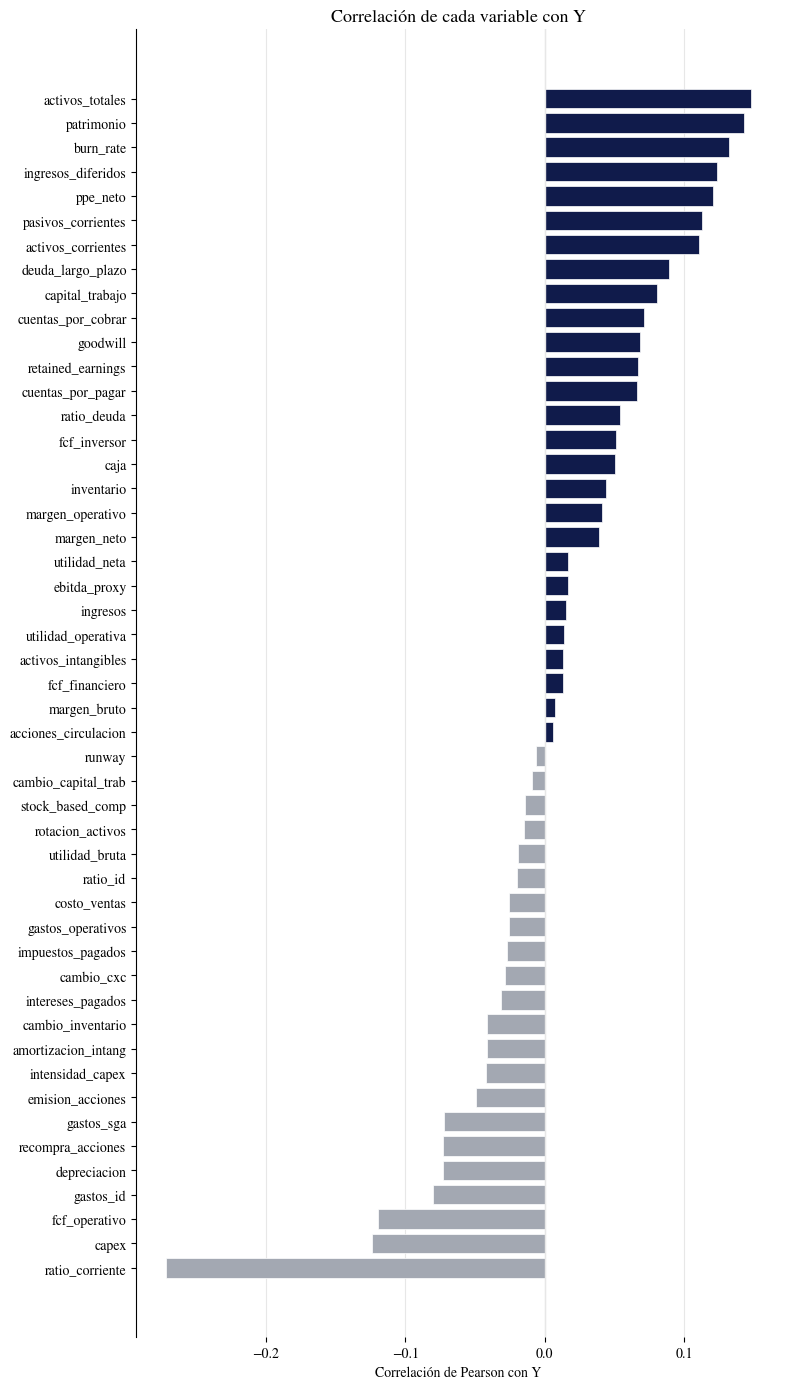

Top 10 más correlacionadas con Y (negativo = predice no-breakeven):
ratio_corriente       -0.272
capex                 -0.124
fcf_operativo         -0.119
gastos_id             -0.080
depreciacion          -0.073
recompra_acciones     -0.073
gastos_sga            -0.073
emision_acciones      -0.049
intensidad_capex      -0.042
amortizacion_intang   -0.041

Top 10 más correlacionadas con Y (positivo = predice breakeven):
cuentas_por_cobrar    0.071
capital_trabajo       0.081
deuda_largo_plazo     0.089
activos_corrientes    0.111
pasivos_corrientes    0.113
ppe_neto              0.121
ingresos_diferidos    0.124
burn_rate             0.132
patrimonio            0.143
activos_totales       0.148


In [75]:
# Correlación de features con Y
correlacion_y = df_modelo[features + ["Y"]].corr()["Y"].drop("Y").sort_values()

fig, ax = plt.subplots(figsize=(8, 14))
estilo_ax(ax, "horizontal")
colores_cor = [juan_colors[2] if v < 0 else juan_colors[0] for v in correlacion_y.values]
ax.barh(correlacion_y.index, correlacion_y.values,
        color=colores_cor, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=juan_colors[3], linewidth=1.0)
ax.set_title("Correlación de cada variable con Y", fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Correlación de Pearson con Y", fontfamily=FUENTE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

print("Top 10 más correlacionadas con Y (negativo = predice no-breakeven):")
print(correlacion_y.head(10).round(3).to_string())
print("\nTop 10 más correlacionadas con Y (positivo = predice breakeven):")
print(correlacion_y.tail(10).round(3).to_string())

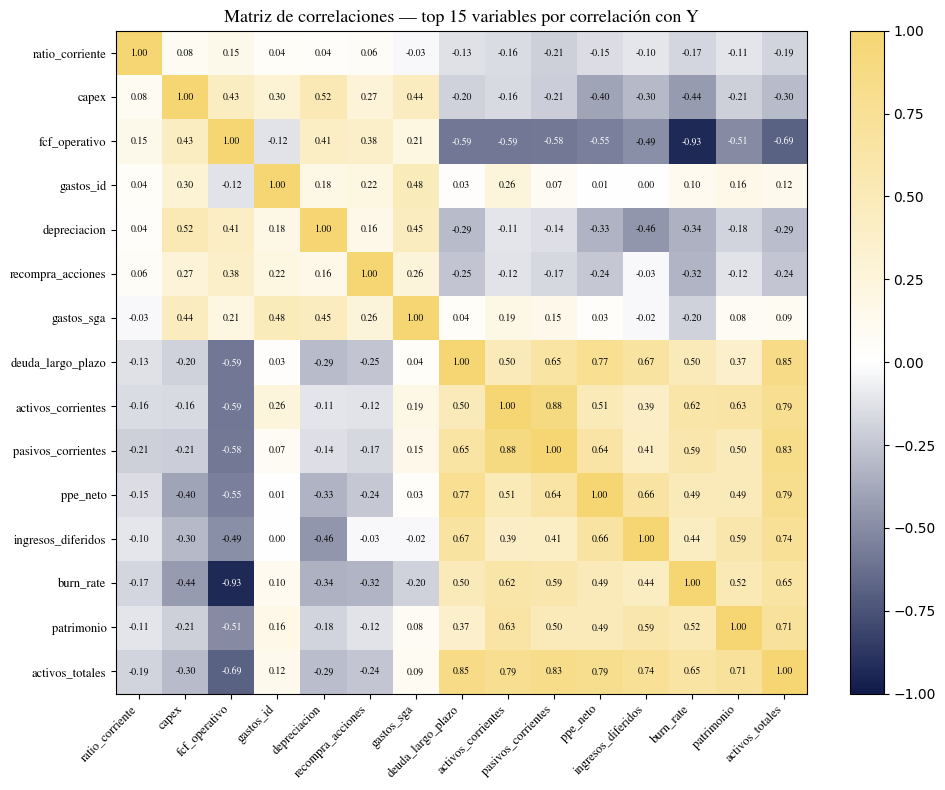

In [76]:
top_features = list(correlacion_y.head(7).index) + list(correlacion_y.tail(8).index)
matriz = df_modelo[top_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz.values, cmap=cmap_custom, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=1)
ax.set_xticks(range(len(top_features)))
ax.set_yticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha="right", fontfamily=FUENTE, fontsize=9)
ax.set_yticklabels(top_features, fontfamily=FUENTE, fontsize=9)
ax.set_title("Matriz de correlaciones — top 15 variables por correlación con Y",
             fontfamily=FUENTE, fontsize=13)
for i in range(len(top_features)):
    for j in range(len(top_features)):
        val = matriz.values[i, j]
        color = "white" if val < -0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=color, fontfamily=FUENTE)
plt.tight_layout()
plt.show()

## 11. Guardar dataset final

El dataset procesado se guarda en `datos/procesados/` listo para el Cuaderno 3 de modelado.

In [77]:
ruta = "../datos/procesados/dataset_modelo.csv"
df_modelo.to_csv(ruta, index=False)

tamano_mb = Path(ruta).stat().st_size / (1024**2)
print(f"Guardado: dataset_modelo.csv")
print(f"Tamaño: {tamano_mb:.1f} MB")
print(f"\n{'='*50}")
print("RESUMEN DEL DATASET")
print(f"{'='*50}")
print(f"  Observaciones:        {len(df_modelo):,}")
print(f"  Empresas:             {df_modelo['ticker'].nunique():,}")
print(f"  Features:             {len(features)}")
print(f"  Variables totales:    {df_modelo.shape[1]}")
print(f"  Período:              {df_modelo['end'].min().date()} → {df_modelo['end'].max().date()}")
print(f"  Y=1 (breakeven):      {df_modelo['Y'].mean()*100:.1f}%")
print(f"  Y=0 (no breakeven):   {(1-df_modelo['Y'].mean())*100:.1f}%")
print(f"  Balance de clases:    {'✓ Excelente (no requiere corrección)' if abs(df_modelo['Y'].mean() - 0.5) < 0.1 else '⚠ Desbalanceado'}")

Guardado: dataset_modelo.csv
Tamaño: 10.8 MB

RESUMEN DEL DATASET
  Observaciones:        27,382
  Empresas:             1,608
  Features:             49
  Variables totales:    56
  Período:              2008-06-27 → 2025-06-30
  Y=1 (breakeven):      48.2%
  Y=0 (no breakeven):   51.8%
  Balance de clases:    ✓ Excelente (no requiere corrección)
